# SWIGGY SALES ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Import Dataset

In [2]:
df = pd.read_excel("/content/swiggy_data.xlsx")

In [3]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


# Metadata of Data

In [5]:
print("No. of Rows:", df.shape[0])

No. of Rows: 197430


In [6]:
print("No. of columns", df.shape[1])

No. of columns 10


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


# Data Types

In [8]:
df.dtypes

,0
State,object
City,object
Order Date,datetime64[ns]
Restaurant Name,object
Location,object
Category,object
Dish Name,object
Price (INR),float64
Rating,float64
Rating Count,int64


In [9]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


# KPI's

# Total Sales

In [10]:
total_sales = df["Price (INR)"].sum()
print("Total Sales (INR):", round(total_sales,2))

Total Sales (INR): 53012505.77


# Average Rating

In [11]:
average_ratings = df["Rating"].mean()
print("Average Rating:", round(average_ratings,1))

Average Rating: 4.3


# Average Order Value

In [12]:
avg_order_value = df["Price (INR)"].mean()
print("Avg Order Value (INR):", round(avg_order_value,2))

Avg Order Value (INR): 268.51


# Ratings Count

In [13]:
ratings_count = df["Rating Count"].sum()
print("Rating Count:", round(ratings_count,2))

Rating Count: 5591574


# Total Orders

In [14]:
print("Total Orders:", len(df))

Total Orders: 197430


In [15]:
total_orders = len(df)
print("Total Orders:", round(total_orders,2))

Total Orders: 197430


# CHARTS DESIGN

# Monthly Sales Trend

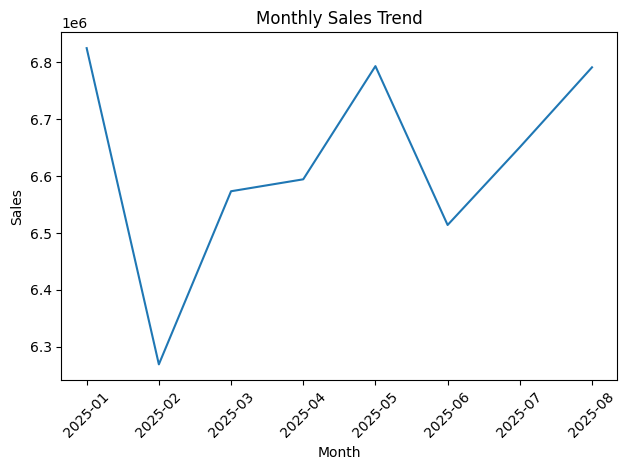

In [16]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_sales["YearMonth"], monthly_sales["Price (INR)"])
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Daily Sales Trend

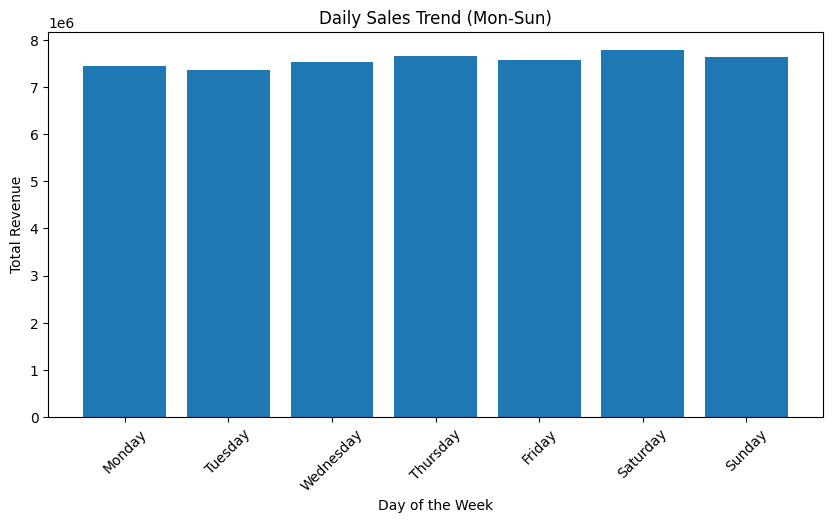

In [17]:
df['DayName'] = pd.to_datetime(df['Order Date']).dt.day_name()

daily_revenue = (
    df.groupby('DayName')['Price (INR)'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
)

plt.figure(figsize=(10, 5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.xlabel('Day of the Week')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue')
plt.title('Daily Sales Trend (Mon-Sun)')
plt.show()

# Total Sales by Food Type(Veg vs Non-Veg)

In [18]:
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton"
    "prawn", "biryani", "kabab", "kebab"
    "non-veg", "non-veg"
]

df["Food Category"] = np.where(df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False), "Non-Veg", "Veg")


In [19]:
food_revenue = (
    df.groupby("Food Category")["Price (INR)"].sum().reset_index()
)

In [20]:
from plotly.graph_objs import Margin
fig = px.pie(food_revenue, values="Price (INR)", names="Food Category",hole=0.5, title="Revenue Contribution: Veg vs Non-Veg",)
fig.update_traces(textinfo="percent+label", pull=[0.05, 0])
fig.update_layout(height=500, margin=dict(t=60, b=40, l=40, r=40))
fig.show()

# Total Sales by Sate (Map Visualization)

In [21]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
    .sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Total Sales by State",
)
fig.update_layout(height=600, yaxis=dict(autorange="reversed"))
fig.show()

# Quarterly Performance Summary

In [22]:
df["Order_Date"] = pd.to_datetime(df["Order Date"])

df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)
quarterly_summary = (
    df.groupby("Quarter", as_index=False)
    .agg(
        Total_Orders=("Order_Date", "count"),
        Total_Sales=("Price (INR)", "sum"),
        Avg_Rating=("Rating", "mean"),
    )
    .sort_values("Quarter")
)
quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

quarterly_summary

,Quarter,Total_Orders,Total_Sales,Avg_Rating
0,2025Q1,73096,19667822.0,4.34
1,2025Q2,74163,19902257.0,4.34
2,2025Q3,50171,13442427.0,4.34


# Top 5 Cities by Sales

In [23]:
top_5_cities = (
    df.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
)
fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"]
)
fig.show()